# Milestone 2: UrbanCart Retention — Who Will Churn?

Retention wants a yes/no flag: will this customer **churn**?

This is a **classification** problem. The target `Churned` is 1 or 0.

**Approach**
1. Import the table
2. Look at the class mix
3. Split features and target
4. Train/test split **before** fitting any model
5. Compare Logistic Regression, a Decision Tree, and an SVM on the held-out test set
6. Recommend one model with a tradeoff


## 1. Setup


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Import the data

Each row is one customer. Change the path if the file is in another folder.


In [30]:
df = pd.read_csv("milestone-2-customer-churn.csv")
print("Shape:", df.shape)
print(df.head())
print(df.dtypes)

Shape: (20000, 6)
   MonthsActive  AvgOrderValue  NumOrdersLastQuarter  DaysSinceLastOrder  \
0             7          34.12                     7                   8   
1            45          23.38                     3                  57   
2            24          94.56                     7                  37   
3            39          46.34                     7                   0   
4             3          39.04                     3                  41   

   SupportTicketsFiled  Churned  
0                    2        0  
1                    1        0  
2                    1        0  
3                    0        0  
4                    2        0  
MonthsActive              int64
AvgOrderValue           float64
NumOrdersLastQuarter      int64
DaysSinceLastOrder        int64
SupportTicketsFiled       int64
Churned                   int64
dtype: object


## 3. Class mix

`Churned` is the target. 1 = left. 0 = stayed.

Only about 8% churned. A model that always says "stayed" is already ~92% accurate and catches nobody. That is why accuracy alone is not enough.


Churned
0    18433
1     1567
Name: count, dtype: int64
Churned
0    0.922
1    0.078
Name: proportion, dtype: float64


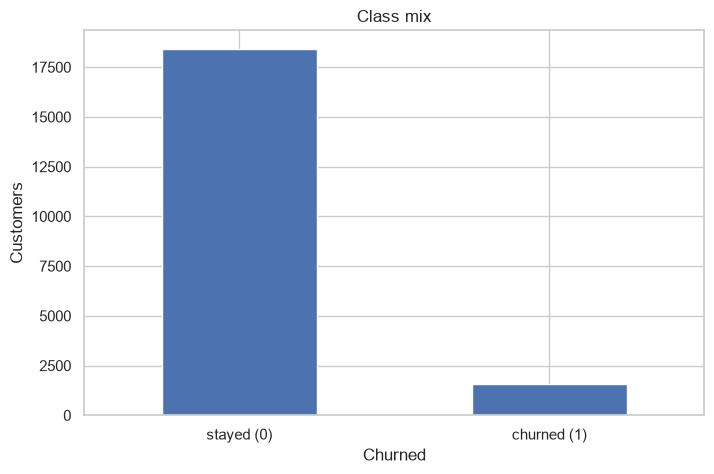

In [31]:
print(df["Churned"].value_counts())
print(df["Churned"].value_counts(normalize=True).round(3))

df["Churned"].value_counts().plot(kind="bar")
plt.xticks([0, 1], ["stayed (0)", "churned (1)"], rotation=0)
plt.ylabel("Customers")
plt.title("Class mix")
plt.show()

## 4. How the features relate to churn


Churned                 1.000000
DaysSinceLastOrder      0.333397
SupportTicketsFiled     0.098857
AvgOrderValue          -0.006756
MonthsActive           -0.041180
NumOrdersLastQuarter   -0.049119
Name: Churned, dtype: float64


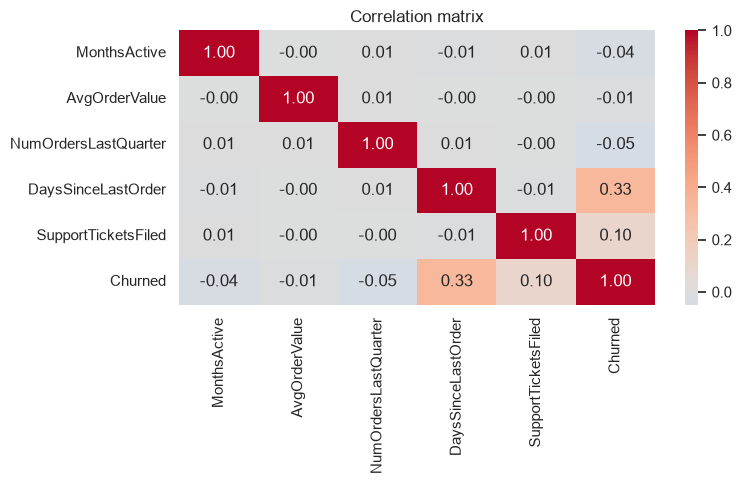

In [32]:
corr = df.corr(numeric_only=True)
print(corr["Churned"].sort_values(ascending=False))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

`DaysSinceLastOrder` has the strongest link. Customers who have not ordered in a while churn more. Support tickets also go up a bit with churn. Average order value barely moves the label.

## 5. Features and target

- `X` = what we already know
- `y` = `Churned`

Every feature is already a number, so no `get_dummies` step.


In [33]:
X = df[["MonthsActive", "AvgOrderValue", "NumOrdersLastQuarter", "DaysSinceLastOrder", "SupportTicketsFiled"]]
y = df["Churned"]

print(X.head())
print(y.head())

   MonthsActive  AvgOrderValue  NumOrdersLastQuarter  DaysSinceLastOrder  \
0             7          34.12                     7                   8   
1            45          23.38                     3                  57   
2            24          94.56                     7                  37   
3            39          46.34                     7                   0   
4             3          39.04                     3                  41   

   SupportTicketsFiled  
0                    2  
1                    1  
2                    1  
3                    0  
4                    2  
0    0
1    0
2    0
3    0
4    0
Name: Churned, dtype: int64


## 6. Train/test split

Split **before** training. `stratify=y` keeps the same ~8% churn rate in train and test.


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train rows:", X_train.shape[0], "churn rate:", round(y_train.mean(), 3))
print("Test rows:", X_test.shape[0], "churn rate:", round(y_test.mean(), 3))

Train rows: 16000 churn rate: 0.078
Test rows: 4000 churn rate: 0.078


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def print_scores(y_true, y_pred, label):
    print(label)
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 3))
    print("Recall   :", round(recall_score(y_true, y_pred, zero_division=0), 3))
    print("F1       :", round(f1_score(y_true, y_pred, zero_division=0), 3))
    print()

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    print(title)
    print(cm)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["stayed", "churned"],
        yticklabels=["stayed", "churned"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

- **Accuracy**: share of all guesses that were right.
- **Precision**: of the people we flagged, how many actually churned.
- **Recall**: of the people who actually churned, how many we caught.
- **F1**: balance of precision and recall.
- **Confusion matrix**: the four counts those metrics come from — TN, FP, FN, TP.


## 7. Dummy baseline

Always predict "stayed" (0). This is the score for doing nothing.


In [36]:
y_dummy = np.zeros(len(y_test), dtype=int)
print_scores(y_test, y_dummy, "Always predict stayed — TEST")

Always predict stayed — TEST
Accuracy : 0.922
Precision: 0.0
Recall   : 0.0
F1       : 0.0



## 8. Model 1 — Logistic Regression

Logistic Regression is the classification version of last milestone's linear model. It outputs a probability of churn, then turns that into 0/1.


In [37]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=1000, random_state=42)
log.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [38]:
y_pred_log_train = log.predict(X_train)
y_pred_log = log.predict(X_test)

print_scores(y_train, y_pred_log_train, "Logistic Regression — TRAIN")
print_scores(y_test, y_pred_log, "Logistic Regression — TEST")


Logistic Regression — TRAIN
Accuracy : 0.927
Precision: 0.684
Recall   : 0.128
F1       : 0.215

Logistic Regression — TEST
Accuracy : 0.927
Precision: 0.75
Recall   : 0.105
F1       : 0.185



The test matrix is the picture behind precision and recall. Top-right = false alarms. Bottom-left = churners we missed.


Logistic Regression — test
[[3676   11]
 [ 280   33]]


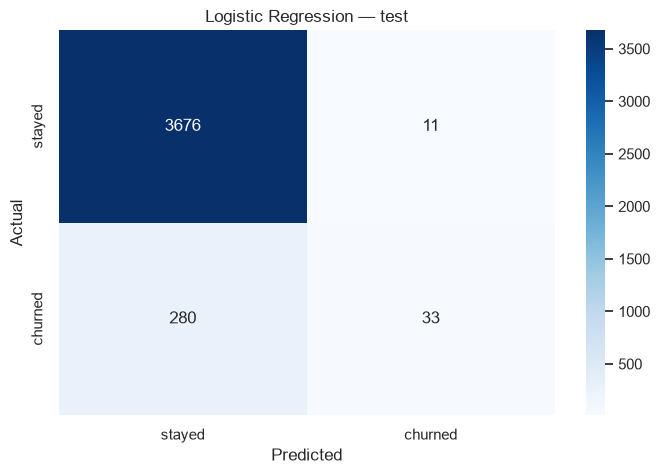

In [39]:
plot_cm(y_test, y_pred_log, "Logistic Regression — test")


## 9. Model 2 — Decision Tree

A Decision Tree splits customers with if/else rules (gap since last order, tickets, and so on) until it assigns 0 or 1.


In [40]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [41]:
y_pred_tree_train = tree.predict(X_train)
y_pred_tree = tree.predict(X_test)

print_scores(y_train, y_pred_tree_train, "Decision Tree — TRAIN")
print_scores(y_test, y_pred_tree, "Decision Tree — TEST")

Decision Tree — TRAIN
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1       : 1.0

Decision Tree — TEST
Accuracy : 0.867
Precision: 0.192
Recall   : 0.217
F1       : 0.204



The test matrix is the picture behind precision and recall. Top-right = false alarms. Bottom-left = churners we missed.


Decision Tree — test
[[3400  287]
 [ 245   68]]


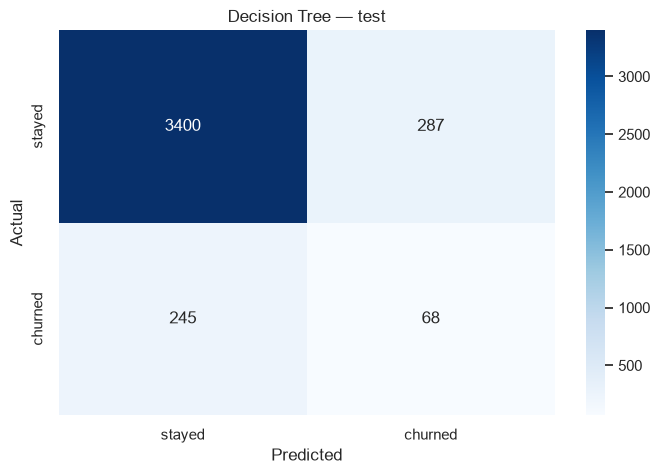

In [42]:
plot_cm(y_test, y_pred_tree, "Decision Tree — test")

## 10. Model 3 — SVM

SVM looks at distance between customers. `AvgOrderValue` and `DaysSinceLastOrder` are different units, so we scale first. Scaling is fit on train only, then applied to test. That is what the pipeline does.


In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", random_state=42))
])
svm.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['MonthsActive','AvgOrderValue','NumOrdersLastQuarter', 'DaysSinceLastOrder','SupportTicketsFiled']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [44]:
y_pred_svm_train = svm.predict(X_train)
y_pred_svm = svm.predict(X_test)

print_scores(y_train, y_pred_svm_train, "SVM — TRAIN")
print_scores(y_test, y_pred_svm, "SVM — TEST")

SVM — TRAIN
Accuracy : 0.928
Precision: 0.795
Recall   : 0.105
F1       : 0.186

SVM — TEST
Accuracy : 0.925
Precision: 0.71
Recall   : 0.07
F1       : 0.128



Same layout for SVM on the same test rows.


SVM — test
[[3678    9]
 [ 291   22]]


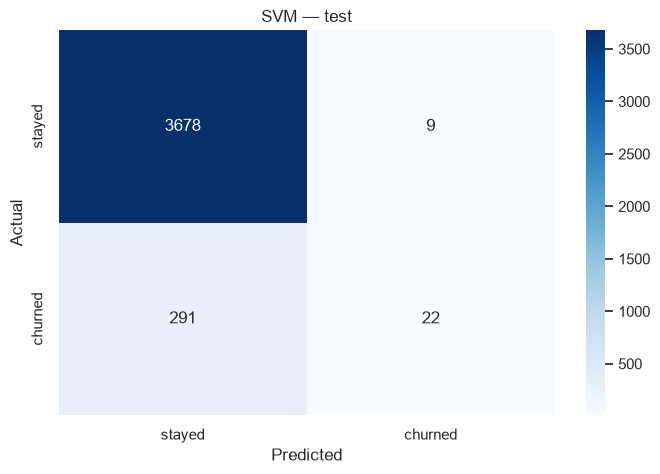

In [45]:
plot_cm(y_test, y_pred_svm, "SVM — test")

## 11. What the models used

Logistic Regression has signed coefficients. The tree has importances. SVM does not give a simple list.


Logistic Regression (positive = more likely to churn)
                Feature  Coefficient
4   SupportTicketsFiled     0.577839
2  NumOrdersLastQuarter    -0.115296
3    DaysSinceLastOrder     0.043330
0          MonthsActive    -0.009806
1         AvgOrderValue    -0.000465

Decision Tree importance
                Feature  Importance
1         AvgOrderValue    0.378443
3    DaysSinceLastOrder    0.285353
0          MonthsActive    0.206477
2  NumOrdersLastQuarter    0.100843
4   SupportTicketsFiled    0.028884
Tree depth: 35


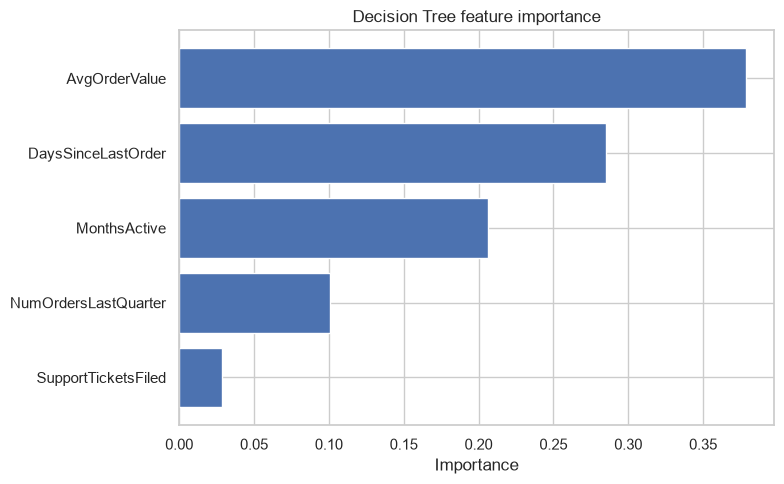

In [46]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)
print("Logistic Regression (positive = more likely to churn)")
print(coef_df)

imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tree.feature_importances_
}).sort_values("Importance", ascending=False)
print("\nDecision Tree importance")
print(imp_df)
print("Tree depth:", tree.get_depth())

plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Decision Tree feature importance")
plt.tight_layout()
plt.show()


## 12. Comparison

| Model | Train F1 | Test accuracy | Test precision | Test recall | Test F1 |
|---|---|---|---|---|---|
| Always predict stayed | — | 0.922 | 0.000 | 0.000 | 0.000 |
| Logistic Regression | 0.215 | 0.927 | 0.750 | 0.105 | 0.185 |
| Decision Tree | 1.000 | 0.867 | 0.192 | 0.217 | 0.204 |
| SVM | 0.186 | 0.925 | 0.710 | 0.070 | 0.128 |

Accuracy is close to the dummy for Logistic Regression and SVM. That is the 8% churn rate talking.

Logistic Regression test matrix: about 33 true flags, 280 missed, 11 false alarms.
SVM: about 22 true flags, 291 missed, 9 false alarms. Train and test stay close.
The default Decision Tree memorizes train (F1 = 1.00). On test, accuracy drops below the dummy. It catches more (about 68) and also creates 287 false alarms.


## 13. Recommendation

**Use Logistic Regression** for the first churn flag.

It matches SVM on stability, beats SVM on recall and F1, and beats the default tree on precision and on not overfitting. The signs are readable: a longer gap since last order and more support tickets raise the chance of churn.

**Tradeoff.** Logistic Regression and SVM both miss most churners so the save-offer list stays small and cleaner. The unrestricted tree catches more and bothers many customers who were staying. If retention wants more names later, change the probability cutoff or cap the tree depth. Do not ship the default tree as-is.

**Limit.** These five columns do not see a bad delivery, an expired card, or a competitor sale.
